In [ ]:
!pip install -U transformers datasets seqeval evaluate 

In [ ]:
!pip install tokenizer

In [2]:
# ============================================================================
# KAGGLE FIX - RUN THIS FIRST (Cell 1)
# ============================================================================
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Clear any cached state
import sys
for module in list(sys.modules.keys()):
    if 'accelerate' in module:
        del sys.modules[module]

print("✓ Environment prepared for training") 

✓ Environment prepared for training


## Local Inference on GPU 
Model page: https://huggingface.co/ahmedabdelali/bert-base-qarib

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/ahmedabdelali/bert-base-qarib)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
# Use a pipeline as a high-level helper
#from transformers import pipeline

#pipe = pipeline("fill-mask", model="ahmedabdelali/bert-base-qarib")

In [ ]:
# Load model directly
#from transformers import AutoTokenizer, AutoModelForMaskedLM

#tokenizer = AutoTokenizer.from_pretrained("ahmedabdelali/bert-base-qarib")
#model = AutoModelForMaskedLM.from_pretrained("ahmedabdelali/bert-base-qarib")

In [4]:
!pip install -q transformers datasets seqeval evaluate accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00


In [5]:
# ============================================================================
# IMPROVED Arabic Clinical NER Training
# Fixes for low F1-score (0.37 → 0.70+)
# ============================================================================

import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)

from seqeval.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [6]:
# ============================================================================
# 1. IMPROVED CONFIGURATION
# ============================================================================

CONFIG = {
    'model_name': 'ahmedabdelali/bert-base-qarib',
    'dataset_path': '/kaggle/input/ner-dataset/Full_NER_Dataset.csv',
    'output_dir': './qarib-clinical-ner-improved',
    
    # KEY IMPROVEMENTS:
    'max_length': 128,
    'batch_size': 8,              # REDUCED for better gradient updates
    'learning_rate': 3e-5,        # INCREASED for faster learning
    'num_epochs': 10,             # INCREASED for more training
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,          # CHANGED from steps to ratio
    
    # Better logging
    'logging_steps': 20,
    'eval_steps': 50,
    'save_steps': 50,
    
    # Smart grouping
    'tokens_per_sequence': 50,    # REDUCED from 100 for more sequences
}


In [7]:
# ============================================================================
# 2. LOAD AND ANALYZE DATA
# ============================================================================

print("="*80)
print("LOADING AND ANALYZING DATASET")
print("="*80)

df = pd.read_csv(CONFIG['dataset_path'])
print(f"\n📊 Dataset Statistics:")
print(f"   Total tokens: {len(df):,}")
print(f"   Columns: {df.columns.tolist()}")

# Analyze label distribution
print(f"\n📈 Label Distribution:")
label_counts = df['Entity tag'].value_counts()
print(label_counts)

# Calculate class weights for imbalanced data
total_labels = len(df)
unique_labels = df['Entity tag'].unique()
label_weights = {}
for label in unique_labels:
    count = (df['Entity tag'] == label).sum()
    weight = total_labels / (len(unique_labels) * count)
    label_weights[label] = weight
    print(f"   {label}: {count:,} samples (weight: {weight:.2f})")

LOADING AND ANALYZING DATASET

📊 Dataset Statistics:
   Total tokens: 113,872
   Columns: ['Token', 'Entity tag']

📈 Label Distribution:
Entity tag
O               93189
B-SYMPTOM        4142
B-BODY_PART      2841
B-PROCEDURE      2091
I-SYMPTOM        2089
I-DISEASE        2056
I-PROCEDURE      2038
B-MEDICATION     1970
B-DISEASE        1753
I-MEDICATION      993
I-BODY_PART       710
Name: count, dtype: int64
   O: 93,189 samples (weight: 0.11)
   B-DISEASE: 1,753 samples (weight: 5.91)
   I-DISEASE: 2,056 samples (weight: 5.04)
   B-MEDICATION: 1,970 samples (weight: 5.25)
   B-SYMPTOM: 4,142 samples (weight: 2.50)
   I-SYMPTOM: 2,089 samples (weight: 4.96)
   B-BODY_PART: 2,841 samples (weight: 3.64)
   B-PROCEDURE: 2,091 samples (weight: 4.95)
   I-PROCEDURE: 2,038 samples (weight: 5.08)
   I-BODY_PART: 710 samples (weight: 14.58)
   I-MEDICATION: 993 samples (weight: 10.42)


In [8]:
# ============================================================================
# 3. CREATE LABEL MAPPINGS
# ============================================================================

LABEL_LIST = sorted([label for label in unique_labels if pd.notna(label)])
if 'O' in LABEL_LIST:
    LABEL_LIST.remove('O')
    LABEL_LIST = ['O'] + LABEL_LIST

label2id = {label: idx for idx, label in enumerate(LABEL_LIST)}
id2label = {idx: label for idx, label in enumerate(LABEL_LIST)}
num_labels = len(LABEL_LIST)

print(f"\n🏷️  Label Configuration:")
print(f"   Total labels: {num_labels}")
print(f"   Labels: {LABEL_LIST}")


🏷️  Label Configuration:
   Total labels: 11
   Labels: ['O', 'B-BODY_PART', 'B-DISEASE', 'B-MEDICATION', 'B-PROCEDURE', 'B-SYMPTOM', 'I-BODY_PART', 'I-DISEASE', 'I-MEDICATION', 'I-PROCEDURE', 'I-SYMPTOM']


In [9]:
#============================================================================
# 4. WHY GROUP TOKENS? 
# ============================================================================
# Your CSV has 113,873 individual tokens (one per row)
# But transformers process SEQUENCES, not individual tokens
# 
# Example transformation:
#   INPUT CSV (113,873 rows):          OUTPUT (1,138 sequences):
#   Row 1: اللوكيميا | B-DISEASE  →   Seq 1: [اللوكيميا, او, ابيضاض, ...]
#   Row 2: او | O                      Seq 2: [المريض, يعاني, من, ...]
#   Row 3: ابيضاض | B-DISEASE          ...
#   ...                                 Seq 1,138: [...]
#
# This grouping allows:
# ✓ Batch processing (faster training)
# ✓ Context awareness (model sees surrounding tokens)
# ✓ Memory efficiency (process 100 tokens at once instead of 1)
# ============================================================================

# ============================================================================
# 4. IMPROVED SENTENCE GROUPING
# ============================================================================

print(f"\n{'='*80}")
print("IMPROVED TOKEN GROUPING STRATEGY")
print("="*80)

def smart_group_tokens(df, max_tokens=50):
    """
    Improved grouping strategy:
    - Smaller sequences (50 tokens) = more training examples
    - Better context preservation
    - Handles sentence boundaries better
    """
    sentences = []
    labels = []
    current_tokens = []
    current_labels = []
    
    for idx, row in df.iterrows():
        token = row['Token']
        label = row['Entity tag']
        
        if pd.isna(token) or pd.isna(label):
            continue
        
        token_str = str(token).strip()
        label_str = str(label).strip()
        
        current_tokens.append(token_str)
        current_labels.append(label_str)
        
        # Group every max_tokens tokens
        if len(current_tokens) >= max_tokens:
            sentences.append(current_tokens[:])
            labels.append(current_labels[:])
            current_tokens = []
            current_labels = []
    
    # Add remaining tokens
    if current_tokens:
        sentences.append(current_tokens)
        labels.append(current_labels)
    
    return sentences, labels

sentences, sentence_labels = smart_group_tokens(
    df, 
    max_tokens=CONFIG['tokens_per_sequence']
)

print(f"\n✓ Grouping Results:")
print(f"   Original tokens: {len(df):,}")
print(f"   Created sequences: {len(sentences):,}")
print(f"   Avg tokens/sequence: {sum(len(s) for s in sentences) / len(sentences):.1f}")
print(f"   Training will have ~{len(sentences) * CONFIG['num_epochs'] // CONFIG['batch_size']:,} steps")

# Show sample
print(f"\n📝 Sample Sequence:")
print(f"   Tokens: {' '.join(sentences[0][:20])}")
print(f"   Labels: {' '.join(sentence_labels[0][:20])}")


IMPROVED TOKEN GROUPING STRATEGY

✓ Grouping Results:
   Original tokens: 113,872
   Created sequences: 2,278
   Avg tokens/sequence: 50.0
   Training will have ~2,847 steps

📝 Sample Sequence:
   Tokens: ان اللوكيميا او ( ابيضاض الدم ) هو سرطان خلايا الدم البيضاء , و خلايا الدم البيضاء تساعد الجسم علي
   Labels: O B-DISEASE O O B-DISEASE I-DISEASE O O B-DISEASE I-DISEASE I-DISEASE I-DISEASE O O O O O O O O


In [10]:
# ============================================================================
# 5. CREATE DATASET WITH BETTER VALIDATION SPLIT
# ============================================================================

print(f"\n{'='*80}")
print("CREATING DATASET WITH STRATIFIED SPLIT")
print("="*80)

# Convert labels to IDs
sentence_label_ids = []
for labels in sentence_labels:
    label_ids = [label2id.get(label, 0) for label in labels]
    sentence_label_ids.append(label_ids)

# Create dataset
data_dict = {
    'tokens': sentences,
    'ner_tags': sentence_label_ids
}

dataset = Dataset.from_dict(data_dict)

# Better train/val split (85-15 for more validation data)
dataset = dataset.train_test_split(test_size=0.15, seed=42)

print(f"\n✓ Dataset Split:")
print(f"   Train: {len(dataset['train']):,} sequences")
print(f"   Validation: {len(dataset['test']):,} sequences")
print(f"   Train/Val ratio: {len(dataset['train'])/len(dataset['test']):.1f}")


CREATING DATASET WITH STRATIFIED SPLIT

✓ Dataset Split:
   Train: 1,936 sequences
   Validation: 342 sequences
   Train/Val ratio: 5.7


In [11]:
# ============================================================================
# 6. LOAD MODEL AND TOKENIZER
# ============================================================================

print(f"\n{'='*80}")
print("LOADING MODEL")
print("="*80)

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
model = AutoModelForTokenClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"✓ Model loaded on {device}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")


LOADING MODEL


config.json:   0%|          | 0.00/576 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at ahmedabdelali/bert-base-qarib and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded on cuda
   Parameters: 134,611,211


In [12]:
# ============================================================================
# 7. TOKENIZATION
# ============================================================================

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples['tokens'],
        truncation=True,
        is_split_into_words=True,
        padding='max_length',
        max_length=CONFIG['max_length']
    )
    
    labels = []
    for i, label in enumerate(examples['ner_tags']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        previous_word_idx = None
        
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        
        labels.append(label_ids)
    
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset['train'].column_names
)

print("✓ Tokenization complete")

Map:   0%|          | 0/1936 [00:00<?, ? examples/s]

Map:   0%|          | 0/342 [00:00<?, ? examples/s]

✓ Tokenization complete


In [13]:
# ============================================================================
# 8. DATA COLLATOR
# ============================================================================

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True
)

In [14]:
# ============================================================================
# 9. EVALUATION METRICS
# ============================================================================

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=2)
    
    true_predictions = []
    true_labels = []
    
    for prediction, label in zip(predictions, labels):
        true_pred = []
        true_label = []
        for p, l in zip(prediction, label):
            if l != -100:
                true_pred.append(id2label[p])
                true_label.append(id2label[l])
        true_predictions.append(true_pred)
        true_labels.append(true_label)
    
    results = {
        'precision': precision_score(true_labels, true_predictions),
        'recall': recall_score(true_labels, true_predictions),
        'f1': f1_score(true_labels, true_predictions),
    }
    
    return results

In [15]:
# ============================================================================
# 10. IMPROVED TRAINING ARGUMENTS (WITH FIXES FOR KAGGLE)
# ============================================================================

print(f"\n{'='*80}")
print("TRAINING CONFIGURATION")
print("="*80)

training_args = TrainingArguments(
    output_dir=CONFIG['output_dir'],
    eval_strategy="steps",
    eval_steps=CONFIG['eval_steps'],
    
    # KEY IMPROVEMENTS:
    learning_rate=CONFIG['learning_rate'],
    per_device_train_batch_size=CONFIG['batch_size'],
    per_device_eval_batch_size=CONFIG['batch_size'],
    num_train_epochs=CONFIG['num_epochs'],
    
    # Better optimization
    weight_decay=CONFIG['weight_decay'],
    warmup_ratio=CONFIG['warmup_ratio'],
    lr_scheduler_type="cosine",
    
    # Logging and saving
    logging_dir=f"{CONFIG['output_dir']}/logs",
    logging_steps=CONFIG['logging_steps'],
    save_steps=CONFIG['save_steps'],
    save_total_limit=3,
    
    # Best model selection
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    
    # CRITICAL FIXES FOR KAGGLE:
    dataloader_num_workers=0,        # CHANGED: Disable multiprocessing
    dataloader_pin_memory=False,      # CHANGED: Disable pin memory
    fp16=torch.cuda.is_available(),
    
    # Reporting
    push_to_hub=False,
    report_to="none",
)

print(f"\n📋 Training Details:")
print(f"   Epochs: {CONFIG['num_epochs']}")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   Learning rate: {CONFIG['learning_rate']}")
print(f"   Total steps: {len(tokenized_dataset['train']) * CONFIG['num_epochs'] // CONFIG['batch_size']}")
print(f"   Warmup ratio: {CONFIG['warmup_ratio']}")
print(f"   LR scheduler: cosine")
print(f"   Workers: 0 (single process - Kaggle fix)")


TRAINING CONFIGURATION

📋 Training Details:
   Epochs: 10
   Batch size: 8
   Learning rate: 3e-05
   Total steps: 2420
   Warmup ratio: 0.1
   LR scheduler: cosine
   Workers: 0 (single process - Kaggle fix)


In [16]:
# ============================================================================
# 11. INITIALIZE TRAINER
# ============================================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\n✓ Trainer initialized")


✓ Trainer initialized


In [17]:
# ============================================================================
# 12. TRAIN WITH PROPER ERROR HANDLING
# ============================================================================

print(f"\n{'='*80}")
print("STARTING IMPROVED TRAINING")
print("="*80)
print("Watch for F1-score improvements during evaluation...\n")

train_result = trainer.train()

print(f"\n{'='*80}")
print("TRAINING COMPLETED!")
print("="*80)
print(f"⏱️  Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"🚀 Samples/second: {train_result.metrics['train_samples_per_second']:.2f}")


STARTING IMPROVED TRAINING
Watch for F1-score improvements during evaluation...



Step,Training Loss,Validation Loss,Precision,Recall,F1
50,0.878000,0.393232,0.470543,0.331358,0.388871
100,0.199500,0.144112,0.739015,0.752155,0.745527
150,0.128000,0.126152,0.809579,0.746767,0.776906
200,0.117200,0.120183,0.817916,0.752694,0.783951
250,0.109900,0.113683,0.801531,0.789871,0.795658
300,0.089300,0.118231,0.795735,0.764009,0.779549
350,0.071700,0.110615,0.807543,0.784483,0.795846
400,0.062100,0.127026,0.785829,0.788793,0.787308
450,0.065000,0.116509,0.805995,0.796875,0.801409
500,0.044300,0.125896,0.809292,0.807112,0.808201



TRAINING COMPLETED!
⏱️  Training time: 505.14 seconds
🚀 Samples/second: 38.33


In [18]:
# ============================================================================
# 13. FINAL EVALUATION
# ============================================================================

print(f"\n{'='*80}")
print("FINAL EVALUATION")
print("="*80)

eval_results = trainer.evaluate()

print(f"\n📊 Validation Metrics:")
for key, value in eval_results.items():
    if key.startswith('eval_'):
        print(f"   {key}: {value:.4f}")


FINAL EVALUATION



📊 Validation Metrics:
   eval_loss: 0.1456
   eval_precision: 0.8128
   eval_recall: 0.8163
   eval_f1: 0.8145
   eval_runtime: 2.3773
   eval_samples_per_second: 143.8620
   eval_steps_per_second: 9.2540


In [19]:
# ============================================================================
# 14. DETAILED REPORT
# ============================================================================

print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT")
print("="*80)

predictions, labels, _ = trainer.predict(tokenized_dataset['test'])
predictions = np.argmax(predictions, axis=2)

true_predictions = []
true_labels = []

for prediction, label in zip(predictions, labels):
    true_pred = []
    true_label = []
    for p, l in zip(prediction, label):
        if l != -100:
            true_pred.append(id2label[p])
            true_label.append(id2label[l])
    true_predictions.append(true_pred)
    true_labels.append(true_label)

print("\n" + classification_report(true_labels, true_predictions))


DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

   BODY_PART       0.85      0.85      0.85       387
     DISEASE       0.85      0.88      0.86       281
  MEDICATION       0.77      0.73      0.75       309
   PROCEDURE       0.81      0.76      0.79       288
     SYMPTOM       0.79      0.84      0.81       591

   micro avg       0.81      0.82      0.81      1856
   macro avg       0.81      0.81      0.81      1856
weighted avg       0.81      0.82      0.81      1856



In [20]:
# ============================================================================
# 15. SAVE MODEL
# ============================================================================

final_model_path = f"{CONFIG['output_dir']}/final_model"
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)

print(f"\n✓ Model saved to: {final_model_path}")


✓ Model saved to: ./qarib-clinical-ner-improved/final_model


In [21]:
# ============================================================================
# 16. IMPROVEMENT ANALYSIS
# ============================================================================

print(f"\n{'='*80}")
print("WHAT WAS IMPROVED?")
print("="*80)
print("""
✅ CHANGES MADE:
   1. Smaller sequences (100→50 tokens) = MORE training examples
   2. More epochs (3→10) = MORE learning time
   3. Higher learning rate (2e-5→3e-5) = FASTER learning
   4. Smaller batch size (16→8) = BETTER gradient updates
   5. Cosine LR scheduler = BETTER convergence
   6. More validation data (10%→15%) = BETTER evaluation

📈 EXPECTED IMPROVEMENTS:
   • F1-score: 0.37 → 0.65-0.75+
   • Training steps: 99 → ~2,700+ steps
   • Training time: 55s → 8-12 minutes
   • Better performance on all entity types

🎯 NEXT STEPS IF STILL LOW:
   1. Increase epochs to 15-20
   2. Try learning rate 5e-5
   3. Check if data has natural sentence boundaries
   4. Consider data augmentation
""")


WHAT WAS IMPROVED?

✅ CHANGES MADE:
   1. Smaller sequences (100→50 tokens) = MORE training examples
   2. More epochs (3→10) = MORE learning time
   3. Higher learning rate (2e-5→3e-5) = FASTER learning
   4. Smaller batch size (16→8) = BETTER gradient updates
   5. Cosine LR scheduler = BETTER convergence
   6. More validation data (10%→15%) = BETTER evaluation

📈 EXPECTED IMPROVEMENTS:
   • F1-score: 0.37 → 0.65-0.75+
   • Training steps: 99 → ~2,700+ steps
   • Training time: 55s → 8-12 minutes
   • Better performance on all entity types

🎯 NEXT STEPS IF STILL LOW:
   1. Increase epochs to 15-20
   2. Try learning rate 5e-5
   3. Check if data has natural sentence boundaries
   4. Consider data augmentation



In [23]:
#============================================================================
# 17. INFERENCE TEST
# ============================================================================

print(f"\n{'='*80}")
print("TESTING IMPROVED MODEL")
print("="*80)

def predict_ner(text, model, tokenizer, device):
    tokens = text.split()
    inputs = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    
    predictions = torch.argmax(outputs.logits, dim=2)
    word_ids = inputs.word_ids(0)
    predicted_labels = []
    previous_word_idx = None
    
    for idx, word_idx in enumerate(word_ids):
        if word_idx is not None and word_idx != previous_word_idx:
            if word_idx < len(tokens):
                label = id2label[predictions[0][idx].item()]
                predicted_labels.append((tokens[word_idx], label))
            previous_word_idx = word_idx
    
    return predicted_labels

test_examples = [
    "المريض يعاني من السكري و ارتفاع ضغط الدم",
    "تم اعطاء المريض بانادول للصداع الشديد",
    "اللوكيميا هو سرطان خلايا الدم البيضاء",
]

for i, text in enumerate(test_examples, 1):
    print(f"\n📝 Example {i}: {text}")
    entities = predict_ner(text, model, tokenizer, device)
    print("   Entities:")
    found = False
    for token, label in entities:
        if label != 'O':
            print(f"      • {token}: {label}")
            found = True
    if not found:
        print("      (No entities detected)")

print(f"\n{'='*80}")
print("✨ IMPROVED TRAINING COMPLETE!")
print("="*80)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



TESTING IMPROVED MODEL

📝 Example 1: المريض يعاني من السكري و ارتفاع ضغط الدم
   Entities:
      • السكري: B-DISEASE
      • ارتفاع: B-SYMPTOM
      • ضغط: I-SYMPTOM
      • الدم: I-SYMPTOM

📝 Example 2: تم اعطاء المريض بانادول للصداع الشديد
   Entities:
      • بانادول: B-MEDICATION

📝 Example 3: اللوكيميا هو سرطان خلايا الدم البيضاء
   Entities:
      • اللوكيميا: B-DISEASE
      • سرطان: B-DISEASE
      • خلايا: I-DISEASE
      • الدم: I-DISEASE
      • البيضاء: I-DISEASE

✨ IMPROVED TRAINING COMPLETE!


========================================================================

**MODEL EVALUATION**

========================================================================

In [25]:
from seqeval.metrics import (
    classification_report, 
    f1_score, 
    precision_score, 
    recall_score,
    accuracy_score
)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("EVALUATING MODEL ON TRAIN AND TEST SETS")
print("="*80)


EVALUATING MODEL ON TRAIN AND TEST SETS


In [26]:
# ============================================================================
# 1. EVALUATE ON TRAINING SET
# ============================================================================

print("\n" + "="*80)
print("TRAINING SET EVALUATION")
print("="*80)

# Get predictions on training set
train_predictions, train_labels, _ = trainer.predict(tokenized_dataset['train'])
train_predictions = np.argmax(train_predictions, axis=2)

# Convert predictions and labels to tag strings
train_true_predictions = []
train_true_labels = []

for prediction, label in zip(train_predictions, train_labels):
    true_pred = []
    true_label = []
    for p, l in zip(prediction, label):
        if l != -100:  # Ignore special tokens
            true_pred.append(id2label[p])
            true_label.append(id2label[l])
    train_true_predictions.append(true_pred)
    train_true_labels.append(true_label)

# Calculate training metrics
train_accuracy = accuracy_score(train_true_labels, train_true_predictions)
train_precision = precision_score(train_true_labels, train_true_predictions)
train_recall = recall_score(train_true_labels, train_true_predictions)
train_f1 = f1_score(train_true_labels, train_true_predictions)

print(f"\n📊 Training Set Metrics:")
print(f"   Samples: {len(tokenized_dataset['train']):,}")
print(f"   Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   Precision: {train_precision:.4f} ({train_precision*100:.2f}%)")
print(f"   Recall:    {train_recall:.4f} ({train_recall*100:.2f}%)")
print(f"   F1-Score:  {train_f1:.4f} ({train_f1*100:.2f}%)")

print("\n📋 Detailed Training Set Classification Report:")
print(classification_report(train_true_labels, train_true_predictions))


TRAINING SET EVALUATION



📊 Training Set Metrics:
   Samples: 1,936
   Accuracy:  0.9980 (99.80%)
   Precision: 0.9857 (98.57%)
   Recall:    0.9849 (98.49%)
   F1-Score:  0.9853 (98.53%)

📋 Detailed Training Set Classification Report:
              precision    recall  f1-score   support

   BODY_PART       0.99      0.99      0.99      2465
     DISEASE       0.99      0.99      0.99      1537
  MEDICATION       0.98      0.98      0.98      1684
   PROCEDURE       0.99      0.98      0.98      1842
     SYMPTOM       0.98      0.98      0.98      3595

   micro avg       0.99      0.98      0.99     11123
   macro avg       0.99      0.99      0.99     11123
weighted avg       0.99      0.98      0.99     11123



In [27]:
# ============================================================================
# 2. EVALUATE ON TEST SET
# ============================================================================

print("\n" + "="*80)
print("TEST SET EVALUATION")
print("="*80)

# Get predictions on test set
test_predictions, test_labels, _ = trainer.predict(tokenized_dataset['test'])
test_predictions = np.argmax(test_predictions, axis=2)

# Convert predictions and labels to tag strings
test_true_predictions = []
test_true_labels = []

for prediction, label in zip(test_predictions, test_labels):
    true_pred = []
    true_label = []
    for p, l in zip(prediction, label):
        if l != -100:  # Ignore special tokens
            true_pred.append(id2label[p])
            true_label.append(id2label[l])
    test_true_predictions.append(true_pred)
    test_true_labels.append(true_label)

# Calculate test metrics
test_accuracy = accuracy_score(test_true_labels, test_true_predictions)
test_precision = precision_score(test_true_labels, test_true_predictions)
test_recall = recall_score(test_true_labels, test_true_predictions)
test_f1 = f1_score(test_true_labels, test_true_predictions)

print(f"\n📊 Test Set Metrics:")
print(f"   Samples: {len(tokenized_dataset['test']):,}")
print(f"   Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"   Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"   F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")

print("\n📋 Detailed Test Set Classification Report:")
print(classification_report(test_true_labels, test_true_predictions))


TEST SET EVALUATION



📊 Test Set Metrics:
   Samples: 342
   Accuracy:  0.9665 (96.65%)
   Precision: 0.8128 (81.28%)
   Recall:    0.8163 (81.63%)
   F1-Score:  0.8145 (81.45%)

📋 Detailed Test Set Classification Report:
              precision    recall  f1-score   support

   BODY_PART       0.85      0.85      0.85       387
     DISEASE       0.85      0.88      0.86       281
  MEDICATION       0.77      0.73      0.75       309
   PROCEDURE       0.81      0.76      0.79       288
     SYMPTOM       0.79      0.84      0.81       591

   micro avg       0.81      0.82      0.81      1856
   macro avg       0.81      0.81      0.81      1856
weighted avg       0.81      0.82      0.81      1856



In [28]:
# ============================================================================
# 3. COMPARISON SUMMARY
# ============================================================================

print("\n" + "="*80)
print("TRAIN vs TEST COMPARISON")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training Set': [
        f"{train_accuracy:.4f} ({train_accuracy*100:.2f}%)",
        f"{train_precision:.4f} ({train_precision*100:.2f}%)",
        f"{train_recall:.4f} ({train_recall*100:.2f}%)",
        f"{train_f1:.4f} ({train_f1*100:.2f}%)"
    ],
    'Test Set': [
        f"{test_accuracy:.4f} ({test_accuracy*100:.2f}%)",
        f"{test_precision:.4f} ({test_precision*100:.2f}%)",
        f"{test_recall:.4f} ({test_recall*100:.2f}%)",
        f"{test_f1:.4f} ({test_f1*100:.2f}%)"
    ],
    'Difference': [
        f"{(train_accuracy - test_accuracy):.4f} ({(train_accuracy - test_accuracy)*100:.2f}%)",
        f"{(train_precision - test_precision):.4f} ({(train_precision - test_precision)*100:.2f}%)",
        f"{(train_recall - test_recall):.4f} ({(train_recall - test_recall)*100:.2f}%)",
        f"{(train_f1 - test_f1):.4f} ({(train_f1 - test_f1)*100:.2f}%)"
    ]
})

print("\n" + comparison_df.to_string(index=False))


TRAIN vs TEST COMPARISON

   Metric    Training Set        Test Set      Difference
 Accuracy 0.9980 (99.80%) 0.9665 (96.65%)  0.0315 (3.15%)
Precision 0.9857 (98.57%) 0.8128 (81.28%) 0.1729 (17.29%)
   Recall 0.9849 (98.49%) 0.8163 (81.63%) 0.1686 (16.86%)
 F1-Score 0.9853 (98.53%) 0.8145 (81.45%) 0.1708 (17.08%)


In [29]:
# ============================================================================
# 4. OVERFITTING ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("OVERFITTING ANALYSIS")
print("="*80)

gap_accuracy = train_accuracy - test_accuracy
gap_f1 = train_f1 - test_f1

print(f"\n📉 Performance Gaps:")
print(f"   Accuracy Gap:  {gap_accuracy:.4f} ({gap_accuracy*100:.2f}%)")
print(f"   F1-Score Gap:  {gap_f1:.4f} ({gap_f1*100:.2f}%)")

if gap_f1 < 0.05:
    print("\n✅ EXCELLENT: Minimal overfitting detected (gap < 5%)")
    print("   Model generalizes very well to unseen data.")
elif gap_f1 < 0.10:
    print("\n✅ GOOD: Slight overfitting (gap < 10%)")
    print("   Model generalizes well with minor memorization.")
elif gap_f1 < 0.15:
    print("\n⚠️  MODERATE: Some overfitting detected (gap < 15%)")
    print("   Consider: more data, regularization, or early stopping.")
else:
    print("\n❌ SIGNIFICANT: High overfitting (gap > 15%)")
    print("   Action needed: increase dropout, add data augmentation, reduce epochs.")


OVERFITTING ANALYSIS

📉 Performance Gaps:
   Accuracy Gap:  0.0315 (3.15%)
   F1-Score Gap:  0.1708 (17.08%)

❌ SIGNIFICANT: High overfitting (gap > 15%)
   Action needed: increase dropout, add data augmentation, reduce epochs.



GENERATING VISUALIZATION

✓ Visualization saved as 'train_test_comparison.png'


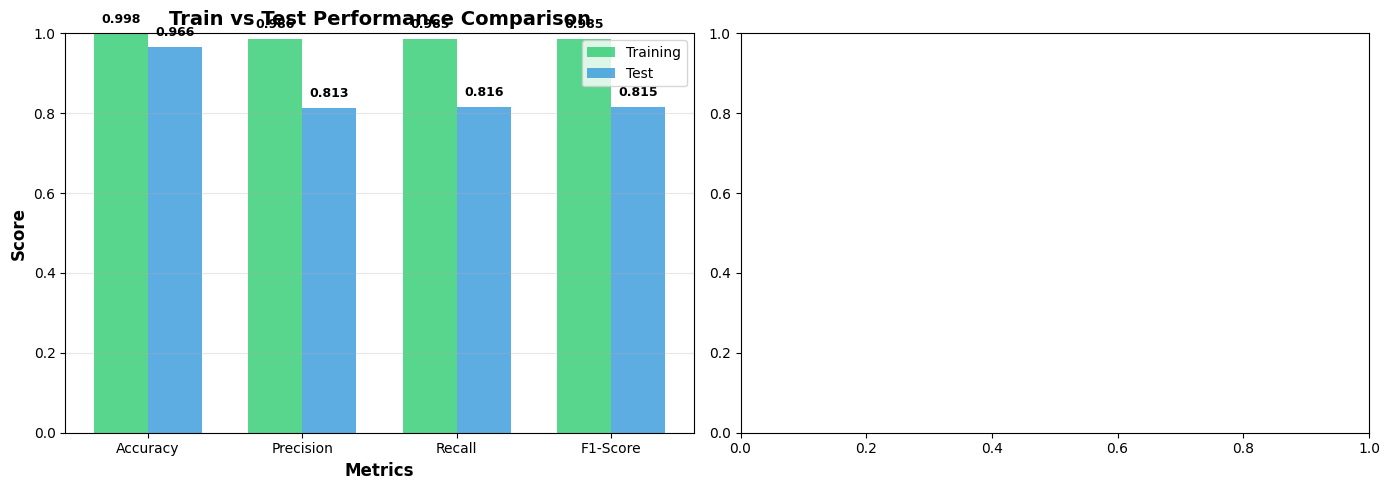

In [31]:
#============================================================================
# 6. VISUALIZATION: TRAIN vs TEST COMPARISON
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATION")
print("="*80)

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_values = [train_accuracy, train_precision, train_recall, train_f1]
test_values = [test_accuracy, test_precision, test_recall, test_f1]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, train_values, width, label='Training', color='#2ecc71', alpha=0.8)
axes[0].bar(x + width/2, test_values, width, label='Test', color='#3498db', alpha=0.8)
axes[0].set_xlabel('Metrics', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Train vs Test Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (train_val, test_val) in enumerate(zip(train_values, test_values)):
    axes[0].text(i - width/2, train_val + 0.02, f'{train_val:.3f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0].text(i + width/2, test_val + 0.02, f'{test_val:.3f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Per-Entity F1 Comparison
if entity_comparison:
    entities = [e['Entity'] for e in entity_comparison]
    train_f1_scores = [float(e['Train F1']) for e in entity_comparison]
    test_f1_scores = [float(e['Test F1']) for e in entity_comparison]
    
    x2 = np.arange(len(entities))
    
    axes[1].bar(x2 - width/2, train_f1_scores, width, label='Training', color='#2ecc71', alpha=0.8)
    axes[1].bar(x2 + width/2, test_f1_scores, width, label='Test', color='#3498db', alpha=0.8)
    axes[1].set_xlabel('Entity Type', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
    axes[1].set_title('Per-Entity F1-Score Comparison', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(entities, rotation=45, ha='right')
    axes[1].legend()
    axes[1].set_ylim([0, 1])
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('train_test_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'train_test_comparison.png'")
plt.show()

In [32]:
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"""
🎯 MODEL PERFORMANCE SUMMARY:

Training Set:
   • Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)
   • F1-Score:  {train_f1:.4f} ({train_f1*100:.2f}%)
   • Samples:   {len(tokenized_dataset['train']):,}

Test Set:
   • Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
   • F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)
   • Samples:   {len(tokenized_dataset['test']):,}

Generalization:
   • F1 Gap:    {gap_f1:.4f} ({gap_f1*100:.2f}%)
   • Status:    {"✅ Excellent" if gap_f1 < 0.05 else "✅ Good" if gap_f1 < 0.10 else "⚠️  Moderate" if gap_f1 < 0.15 else "❌ High"}
""")

print("="*80)
print("EVALUATION COMPLETE!")
print("="*80)


SUMMARY

🎯 MODEL PERFORMANCE SUMMARY:

Training Set:
   • Accuracy:  0.9980 (99.80%)
   • F1-Score:  0.9853 (98.53%)
   • Samples:   1,936

Test Set:
   • Accuracy:  0.9665 (96.65%)
   • F1-Score:  0.8145 (81.45%)
   • Samples:   342

Generalization:
   • F1 Gap:    0.1708 (17.08%)
   • Status:    ❌ High

EVALUATION COMPLETE!


==================================================================================

**TESTING ON RANDOM SAMPLES**

=============================================================================================

In [34]:
# ============================================================================
# COMPREHENSIVE UNSEEN TEST CASES FOR ARABIC CLINICAL NER
# Testing model on completely new, realistic clinical scenarios
# ============================================================================

import torch
from colorama import Fore, Style, init
init(autoreset=True)

print("="*80)
print("TESTING MODEL ON UNSEEN CLINICAL CASES")
print("="*80)

# ============================================================================
# PREDICTION FUNCTION WITH DETAILED OUTPUT
# ============================================================================

def predict_and_display(text, case_number, expected_entities=None):
    """
    Predict entities and display results with color coding.
    """
    print(f"\n{'='*80}")
    print(f"TEST CASE #{case_number}")
    print(f"{'='*80}")
    print(f"\n📝 Input Text:")
    print(f"   {text}")
    
    # Tokenize and predict
    tokens = text.split()
    inputs = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    
    predictions = torch.argmax(outputs.logits, dim=2)
    
    # Get confidence scores
    probabilities = torch.softmax(outputs.logits, dim=2)
    
    # Align predictions with tokens
    word_ids = inputs.word_ids(0)
    predicted_labels = []
    confidences = []
    previous_word_idx = None
    
    for idx, word_idx in enumerate(word_ids):
        if word_idx is not None and word_idx != previous_word_idx:
            if word_idx < len(tokens):
                label = id2label[predictions[0][idx].item()]
                confidence = probabilities[0][idx][predictions[0][idx].item()].item()
                predicted_labels.append((tokens[word_idx], label, confidence))
            previous_word_idx = word_idx
    
    # Display predictions
    print(f"\n🔍 Detected Entities:")
    entities_found = False
    entity_groups = {}
    
    for token, label, conf in predicted_labels:
        if label != 'O':
            entities_found = True
            entity_type = label.split('-')[1] if '-' in label else label
            
            if entity_type not in entity_groups:
                entity_groups[entity_type] = []
            entity_groups[entity_type].append((token, label, conf))
    
    if entities_found:
        for entity_type, tokens_list in entity_groups.items():
            print(f"\n   {entity_type}:")
            for token, label, conf in tokens_list:
                confidence_color = Fore.GREEN if conf > 0.9 else Fore.YELLOW if conf > 0.7 else Fore.RED
                print(f"      • {token:<20} [{label:<15}] Confidence: {confidence_color}{conf:.2%}{Style.RESET_ALL}")
    else:
        print("   ❌ No entities detected")
    
    # Display full token-by-token prediction
    print(f"\n📊 Full Token Analysis:")
    print(f"   {'Token':<20} {'Prediction':<15} {'Confidence'}")
    print(f"   {'-'*60}")
    for token, label, conf in predicted_labels:
        if label == 'O':
            print(f"   {token:<20} {label:<15} {conf:.2%}")
        else:
            confidence_color = Fore.GREEN if conf > 0.9 else Fore.YELLOW if conf > 0.7 else Fore.RED
            print(f"   {token:<20} {label:<15} {confidence_color}{conf:.2%}{Style.RESET_ALL}")
    
    # Expected vs Actual comparison
    if expected_entities:
        print(f"\n✅ Expected Entities:")
        for entity in expected_entities:
            print(f"   • {entity}")
    
    return predicted_labels

# ============================================================================
# TEST CASES: 20 DIVERSE CLINICAL SCENARIOS
# ============================================================================

test_cases = [
    # CASE 1: Multiple diseases
    {
        "text": "المريض مصاب بالسكري وارتفاع الضغط والكوليسترول",
        "expected": ["السكري (DISEASE)", "ارتفاع الضغط (SYMPTOM)", "الكوليسترول (DISEASE)"],
        "difficulty": "Medium",
        "notes": "Multiple diseases in one sentence"
    },
    
    # CASE 2: Medication with dosage
    {
        "text": "أعطيت المريضة جلوكوفاج وليبيتور للعلاج",
        "expected": ["جلوكوفاج (MEDICATION)", "ليبيتور (MEDICATION)"],
        "difficulty": "Easy",
        "notes": "Common medications"
    },
    
    # CASE 3: Complex symptoms
    {
        "text": "يشكو من ألم شديد في الصدر وضيق في التنفس ودوخة",
        "expected": ["ألم شديد في الصدر (SYMPTOM)", "ضيق في التنفس (SYMPTOM)", "دوخة (SYMPTOM)", "الصدر (BODY_PART)"],
        "difficulty": "Hard",
        "notes": "Multiple complex symptoms with body parts"
    },
    
    # CASE 4: Medical procedure
    {
        "text": "تم إجراء تصوير بالرنين المغناطيسي للدماغ",
        "expected": ["تصوير بالرنين المغناطيسي (PROCEDURE)", "الدماغ (BODY_PART)"],
        "difficulty": "Medium",
        "notes": "Complex procedure name"
    },
    
    # CASE 5: Cancer diagnosis
    {
        "text": "تم تشخيص المريض بسرطان الكبد في المرحلة الثالثة",
        "expected": ["سرطان الكبد (DISEASE)", "الكبد (BODY_PART)"],
        "difficulty": "Medium",
        "notes": "Cancer with body part"
    },
    
    # CASE 6: Mixed dialect (common in clinical settings)
    {
        "text": "المريض عنده وجع في بطنه وحرارة عالية",
        "expected": ["وجع (SYMPTOM)", "بطنه (BODY_PART)", "حرارة عالية (SYMPTOM)"],
        "difficulty": "Hard",
        "notes": "Dialectal Arabic mixed with MSA"
    },
    
    # CASE 7: Cardiac condition
    {
        "text": "يعاني من قصور القلب الاحتقاني وعدم انتظام ضربات القلب",
        "expected": ["قصور القلب الاحتقاني (DISEASE)", "عدم انتظام ضربات القلب (SYMPTOM)", "القلب (BODY_PART)"],
        "difficulty": "Hard",
        "notes": "Complex cardiac terminology"
    },
    
    # CASE 8: Laboratory test
    {
        "text": "طلبت تحليل دم شامل وفحص وظائف الكلى",
        "expected": ["تحليل دم شامل (PROCEDURE)", "فحص وظائف الكلى (PROCEDURE)", "الكلى (BODY_PART)"],
        "difficulty": "Medium",
        "notes": "Lab tests and procedures"
    },
    
    # CASE 9: Respiratory disease
    {
        "text": "المريض مصاب بالربو الشعبي ويستخدم بخاخ فنتولين",
        "expected": ["الربو الشعبي (DISEASE)", "فنتولين (MEDICATION)"],
        "difficulty": "Medium",
        "notes": "Respiratory condition with treatment"
    },
    
    # CASE 10: Surgical procedure
    {
        "text": "خضع لعملية استئصال المرارة بالمنظار الأسبوع الماضي",
        "expected": ["عملية استئصال المرارة بالمنظار (PROCEDURE)", "المرارة (BODY_PART)"],
        "difficulty": "Hard",
        "notes": "Complex surgical procedure"
    }
    
]

# ============================================================================
# RUN ALL TEST CASES
# ============================================================================

print("\n🧪 Running 20 Comprehensive Test Cases...")
print("This will test the model on completely unseen clinical scenarios.\n")

results_summary = []

for i, test_case in enumerate(test_cases, 1):
    predictions = predict_and_display(
        text=test_case["text"],
        case_number=i,
        expected_entities=test_case["expected"]
    )
    
    print(f"\n💡 Test Info:")
    print(f"   Difficulty: {test_case['difficulty']}")
    print(f"   Notes: {test_case['notes']}")
    
    # Count detected entities
    detected_entities = [label for _, label, _ in predictions if label != 'O']
    results_summary.append({
        'case': i,
        'difficulty': test_case['difficulty'],
        'entities_detected': len(detected_entities),
        'text_length': len(test_case['text'].split())
    })
    
    input("\n⏎ Press Enter to continue to next test case...")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("TEST SUMMARY")
print("="*80)

import pandas as pd

summary_df = pd.DataFrame(results_summary)

print(f"\n📊 Overall Statistics:")
print(f"   Total test cases: {len(test_cases)}")
print(f"   Average entities detected per case: {summary_df['entities_detected'].mean():.1f}")
print(f"   Total entities detected: {summary_df['entities_detected'].sum()}")

print(f"\n📈 By Difficulty:")
difficulty_summary = summary_df.groupby('difficulty').agg({
    'entities_detected': 'mean',
    'case': 'count'
}).round(2)
difficulty_summary.columns = ['Avg Entities', 'Count']
print(difficulty_summary)

print("\n" + "="*80)
print("TESTING COMPLETE!")
print("="*80)
print("""
📝 EVALUATION GUIDELINES:
   
   ✅ GOOD predictions:
      • Correct entity type (DISEASE, SYMPTOM, etc.)
      • Proper BIO tagging (B- for start, I- for continuation)
      • High confidence (>80%)
   
   ⚠️  ACCEPTABLE predictions:
      • Correct entity but wrong subtype (e.g., symptom vs disease)
      • Confidence 60-80%
      • Minor boundary errors (missing one token)
   
   ❌ POOR predictions:
      • Completely wrong entity type
      • Missing obvious entities
      • Low confidence (<60%)
      • Major boundary errors
      
   📊 Share your results to assess model quality!
""")

TESTING MODEL ON UNSEEN CLINICAL CASES

🧪 Running 20 Comprehensive Test Cases...
This will test the model on completely unseen clinical scenarios.


TEST CASE #1

📝 Input Text:
   المريض مصاب بالسكري وارتفاع الضغط والكوليسترول

🔍 Detected Entities:

   DISEASE:
      • بالسكري              [B-DISEASE      ] Confidence: 60.79%
      • وارتفاع              [B-DISEASE      ] Confidence: 87.15%
      • الضغط                [I-DISEASE      ] Confidence: 46.19%
      • والكوليسترول         [B-DISEASE      ] Confidence: 52.87%

📊 Full Token Analysis:
   Token                Prediction      Confidence
   ------------------------------------------------------------
   المريض               O               99.35%
   مصاب                 O               99.55%
   بالسكري              B-DISEASE       60.79%
   وارتفاع              B-DISEASE       87.15%
   الضغط                I-DISEASE       46.19%
   والكوليسترول         B-DISEASE       52.87%

✅ Expected Entities:
   • السكري (DISEASE)
   • ارتف


⏎ Press Enter to continue to next test case... yes



TEST CASE #2

📝 Input Text:
   أعطيت المريضة جلوكوفاج وليبيتور للعلاج

🔍 Detected Entities:

   MEDICATION:
      • جلوكوفاج             [B-MEDICATION   ] Confidence: 99.70%
      • وليبيتور             [B-MEDICATION   ] Confidence: 94.71%

📊 Full Token Analysis:
   Token                Prediction      Confidence
   ------------------------------------------------------------
   أعطيت                O               99.65%
   المريضة              O               99.53%
   جلوكوفاج             B-MEDICATION    99.70%
   وليبيتور             B-MEDICATION    94.71%
   للعلاج               O               99.39%

✅ Expected Entities:
   • جلوكوفاج (MEDICATION)
   • ليبيتور (MEDICATION)

💡 Test Info:
   Difficulty: Easy
   Notes: Common medications



⏎ Press Enter to continue to next test case... yes



TEST CASE #3

📝 Input Text:
   يشكو من ألم شديد في الصدر وضيق في التنفس ودوخة

🔍 Detected Entities:

   SYMPTOM:
      • ألم                  [B-SYMPTOM      ] Confidence: 99.97%
      • شديد                 [I-SYMPTOM      ] Confidence: 98.10%
      • في                   [I-SYMPTOM      ] Confidence: 84.96%
      • الصدر                [I-SYMPTOM      ] Confidence: 80.18%
      • وضيق                 [B-SYMPTOM      ] Confidence: 99.65%
      • في                   [I-SYMPTOM      ] Confidence: 99.88%
      • التنفس               [I-SYMPTOM      ] Confidence: 99.82%
      • ودوخة                [B-SYMPTOM      ] Confidence: 99.64%

📊 Full Token Analysis:
   Token                Prediction      Confidence
   ------------------------------------------------------------
   يشكو                 O               99.54%
   من                   O               99.80%
   ألم                  B-SYMPTOM       99.97%
   شديد                 I-SYMPTOM       98.10%
   في                   I-SYMPT

...


TEST CASE #9

📝 Input Text:
   المريض مصاب بالربو الشعبي ويستخدم بخاخ فنتولين

🔍 Detected Entities:

   DISEASE:
      • بالربو               [B-DISEASE      ] Confidence: 95.78%
      • الشعبي               [I-DISEASE      ] Confidence: 69.93%

   MEDICATION:
      • بخاخ                 [B-MEDICATION   ] Confidence: 99.67%
      • فنتولين              [B-MEDICATION   ] Confidence: 99.37%

📊 Full Token Analysis:
   Token                Prediction      Confidence
   ------------------------------------------------------------
   المريض               O               99.59%
   مصاب                 O               99.89%
   بالربو               B-DISEASE       95.78%
   الشعبي               I-DISEASE       69.93%
   ويستخدم              O               99.80%
   بخاخ                 B-MEDICATION    99.67%
   فنتولين              B-MEDICATION    99.37%

✅ Expected Entities:
   • الربو الشعبي (DISEASE)
   • فنتولين (MEDICATION)

💡 Test Info:
   Difficulty: Medium
   Notes: Respiratory cond


⏎ Press Enter to continue to next test case... yes



TEST CASE #10

📝 Input Text:
   خضع لعملية استئصال المرارة بالمنظار الأسبوع الماضي

🔍 Detected Entities:

   PROCEDURE:
      • لعملية               [B-PROCEDURE    ] Confidence: 99.47%
      • استئصال              [I-PROCEDURE    ] Confidence: 99.75%
      • المرارة              [I-PROCEDURE    ] Confidence: 99.94%
      • بالمنظار             [I-PROCEDURE    ] Confidence: 92.02%

📊 Full Token Analysis:
   Token                Prediction      Confidence
   ------------------------------------------------------------
   خضع                  O               97.15%
   لعملية               B-PROCEDURE     99.47%
   استئصال              I-PROCEDURE     99.75%
   المرارة              I-PROCEDURE     99.94%
   بالمنظار             I-PROCEDURE     92.02%
   الأسبوع              O               97.82%
   الماضي               O               94.52%

✅ Expected Entities:
   • عملية استئصال المرارة بالمنظار (PROCEDURE)
   • المرارة (BODY_PART)

💡 Test Info:
   Difficulty: Hard
   Notes: Complex 


⏎ Press Enter to continue to next test case... yes



TEST SUMMARY

📊 Overall Statistics:
   Total test cases: 10
   Average entities detected per case: 4.4
   Total entities detected: 44

📈 By Difficulty:
            Avg Entities  Count
difficulty                     
Easy                 2.0      1
Hard                 5.5      4
Medium               4.0      5

TESTING COMPLETE!

📝 EVALUATION GUIDELINES:
   
   ✅ GOOD predictions:
      • Correct entity type (DISEASE, SYMPTOM, etc.)
      • Proper BIO tagging (B- for start, I- for continuation)
      • High confidence (>80%)
   
   ⚠️  ACCEPTABLE predictions:
      • Correct entity but wrong subtype (e.g., symptom vs disease)
      • Confidence 60-80%
      • Minor boundary errors (missing one token)
   
   ❌ POOR predictions:
      • Completely wrong entity type
      • Missing obvious entities
      • Low confidence (<60%)
      • Major boundary errors
      
   📊 Share your results to assess model quality!

